In [11]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from random import choice
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. ГЕНЕРАТОР ПОСЛЕДОВАТЕЛЬНОСТЕЙ СИМВОЛОВ

In [12]:
class SymbolSequenceGenerator:
    def __init__(self, data_path: str, train_size: float = 0.8, spacing: int = 30):
        self.data_path = data_path
        self.train_size = train_size
        self.spacing = spacing

    def create_sequence_image(self, length: int):
        sequence, images = self._generate_list_of_images(length)
        if not images:
            raise ValueError("No images were generated — check dataset path and structure.")

        total_width = sum(img.shape[1] for img in images) + self.spacing * (len(images) - 1)
        max_height = max(img.shape[0] for img in images) + 10

        # White background
        sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255

        x_offset = 0
        for img in images:
            h, w = img.shape
            y_offset = (max_height - h) // 2  # Center vertically
            sequence_img[y_offset:y_offset + h, x_offset:x_offset + w] = img
            x_offset += w + self.spacing

        return sequence, cv2.bitwise_not(sequence_img)
    
    def _generate_list_of_images(self, length: int):
        available_symbols = self._get_available_symbols(self.data_path)
        sequence = [choice(available_symbols) for _ in range(length)]
        sequence_normalized = [self._normalize_symbol_name(sym) for sym in sequence]
        print(f"Генерация последовательности: {sequence_normalized}")

        images = []
        for char in sequence:
            img = self._get_random_symbol_image(char)
            if img is not None:
                images.append(img)
        
        return sequence_normalized, images

    def _get_random_symbol_image(self, folder_name: str):
        symbol_dir = os.path.join(self.data_path, folder_name)
        images = sorted(os.listdir(symbol_dir))
        start_idx = int(len(images) * self.train_size)
        subset = images[start_idx:]
        if not subset:
            subset = images

        random_image = choice(subset)
        img_path = os.path.join(symbol_dir, random_image)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            return None
    
        return img
    
    @staticmethod
    def _normalize_symbol_name(symbol: str):
        mapping = {'X': 'x', 'times': '*'}
        return mapping.get(symbol, symbol)
    
    @staticmethod
    def _get_available_symbols(data_path: str):
        subfolders = [
            name for name in next(os.walk(data_path))[1]
            if not name.startswith('.')
        ]
        return subfolders

def show_image(img: np.ndarray):
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 2. ЗАГРУЗКА ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ

In [13]:
class DataLoader:
    def load_data(self, data_path: str, train_ratio: float = 0.8):
        X, Y = [], []
        symbols = self._get_available_symbols(data_path)
        print(f"Найдено символов: {symbols}")

        for symbol in symbols:
            symbol_dir = os.path.join(data_path, symbol)
            images = sorted(os.listdir(symbol_dir))
            if not images:
                print(f"  Предупреждение: нет изображений для символа '{symbol}'")
                continue

            label = self._normalize_symbol_name(symbol)
            for img_name in images:
                img_path = os.path.join(symbol_dir, img_name)
                img_vector = self._load_image(img_path)
                if img_vector is not None:
                    X.append(img_vector)
                    Y.append(label)

        X = np.array(X)
        Y = np.array(Y)
        print(f"Всего загружено изображений: {len(X)}")

        # Разделение на обучающую и тестовую выборки
        X_train, X_test, Y_train, Y_test = train_test_split(
            X, Y, train_size=train_ratio, stratify=Y, random_state=42
        )
        print(f"Обучающая выборка: {len(X_train)}")
        print(f"Тестовая выборка: {len(X_test)}")
        
        return X_train, X_test, Y_train, Y_test
    
    @staticmethod
    def _get_available_symbols(data_path: str):
        return [name for name in next(os.walk(data_path))[1] if not name.startswith('.')]

    @staticmethod
    def _normalize_symbol_name(symbol: str):
        mapping = {'X': 'x', 'times': '*'}
        return mapping.get(symbol, symbol)

    @staticmethod
    def _load_image(img_path: str):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        return img.flatten()

class ModelComparator:
    def __init__(self):
        self.model_results = {}
        
    def add_model_result(self, model_name: str, model: KNeighborsClassifier, accuracy: float):
        self.model_results[model_name] = {
            'model': model,
            'accuracy': accuracy
        }
        
    def compare_models(self):
        for name, result in sorted(self.model_results.items()):
            print(f"{name}: Accuracy = {result['accuracy']:.4f}")
        
        if self.model_results:
            best_name = max(self.model_results.keys(), 
                          key=lambda x: self.model_results[x]['accuracy'])
            best_result = self.model_results[best_name]
            return best_name, best_result['model'], best_result['accuracy']

        return None, None, None

# 3. ОСНОВНОЙ КОД

In [14]:
# Загрузка данных
print("Загрузка данных...")
data_loader = DataLoader()
X_train, X_test, Y_train, Y_test = data_loader.load_data("./data")

# Обучение моделей
print("\nОбучение моделей KNN...")
comparator = ModelComparator()

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, Y_train)
accuracy_knn1 = accuracy_score(Y_test, knn1.predict(X_test))
comparator.add_model_result("KNN-1", knn1, accuracy_knn1)
print(f"KNN-1 accuracy: {accuracy_knn1:.4f}")

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, Y_train)
accuracy_knn3 = accuracy_score(Y_test, knn3.predict(X_test))
comparator.add_model_result("KNN-3", knn3, accuracy_knn3)
print(f"KNN-3 accuracy: {accuracy_knn3:.4f}")

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, Y_train)
accuracy_knn5 = accuracy_score(Y_test, knn5.predict(X_test))
comparator.add_model_result("KNN-5", knn5, accuracy_knn5)
print(f"KNN-5 accuracy: {accuracy_knn5:.4f}")

best_name, best_knn_model, best_accuracy = comparator.compare_models()
print(f"Лучшая модель: {best_name} с точностью {best_accuracy:.4f}")

Загрузка данных...
Найдено символов: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'h', 't', 'times', 'w', 'X', 'y']
Всего загружено изображений: 225291
Обучающая выборка: 180232
Тестовая выборка: 45059

Обучение моделей KNN...
KNN-1 accuracy: 0.9885
KNN-3 accuracy: 0.9202
KNN-5 accuracy: 0.7843
KNN-1: Accuracy = 0.9885
KNN-3: Accuracy = 0.9202
KNN-5: Accuracy = 0.7843
Лучшая модель: KNN-1 с точностью 0.9885


# 4. РАСПОЗНАВАНИЕ ПОСЛЕДОВАТЕЛЬНОСТИ

Генерация последовательности: ['6', '5', '5', '6', '8', ')', '2', 'w', '6', 't']


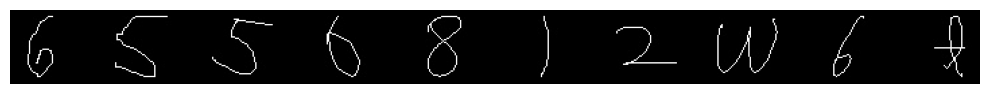

Thresh shape: (55, 720, 3)
1: [13, 5, 19, 45]
2: [78, 5, 39, 45]
3: [150, 7, 45, 41]
4: [235, 5, 25, 45]
5: [310, 5, 25, 45]
6: [394, 5, 6, 45]
7: [450, 13, 45, 28]
8: [525, 7, 45, 40]
9: [611, 5, 23, 45]
10: [686, 5, 23, 45]


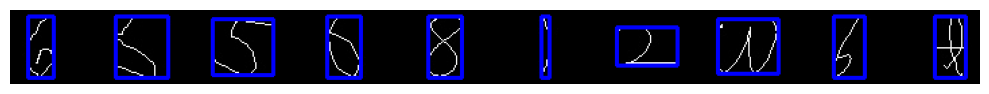

Predicted sequence: 6 5 5 6 8 ) 2 w 6 t
Expected sequence: 6 5 5 6 8 ) 2 w 6 t
Accuracy: 1.0


In [15]:
# Создание генератора
generator = SymbolSequenceGenerator('./data')

# 1. Генерация изображения с последовательностью символов
sequence, img_gray = generator.create_sequence_image(10)
image_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

show_image(img_gray)

# 2. Выделение объектов
_, thresh = cv2.threshold(image_rgb, 127, 255, 0)
print("Thresh shape:", thresh.shape)
thresh = np.uint8(thresh)

contours, h = cv2.findContours(thresh[:,:,0], cv2.RETR_EXTERNAL, 2)
crops = []
for i in range(len(contours)):
    cnt = contours[i]
    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    if w*h > 50:
        cv2.rectangle(image_rgb,(x,y),(x+w,y+h),(0,0,255),2)
        ret,thresh = cv2.threshold(img_gray[y:y+h, x:x+w],127,255,0)
        crops.append([x,y,w,h]) 
        
crops.sort(key=lambda x: x[0])

# Show crops
for idx, crop in enumerate(crops):
    print(f'{idx + 1}:', crop)

show_image(image_rgb)

# Функции для обработки изображений
def pad_to_size(img, target_size=(45, 45)):
    h, w = img.shape
    target_h, target_w = target_size
    
    padded = np.zeros(target_size, dtype=np.uint8)
    y_start = (target_h - h) // 2
    x_start = (target_w - w) // 2
    
    padded[y_start:y_start+h, x_start:x_start+w] = img
    return padded

def pad_and_crop(img, target_size=(45, 45), threshold=10):
    h, w = img.shape
    target_h, target_w = target_size
    
    if h == target_h and w == target_w:
        return img
    
    if h > target_h or w > target_w:
        # Обрезаем черные края
        non_zero_rows = np.where(np.max(img, axis=1) > threshold)[0]
        non_zero_cols = np.where(np.max(img, axis=0) > threshold)[0]
        
        if len(non_zero_rows) > 0 and len(non_zero_cols) > 0:
            y1, y2 = non_zero_rows[0], non_zero_rows[-1] + 1
            x1, x2 = non_zero_cols[0], non_zero_cols[-1] + 1
            img = img[y1:y2, x1:x2]
        
        # Масштабируем
        h, w = img.shape
        scale = min(target_h / h, target_w / w)
        if scale < 1.0:
            new_h, new_w = int(h * scale), int(w * scale)
            img = cv2.resize(img, (new_w, new_h))
    
    return pad_to_size(img, target_size)

# Подготовка изображений символов
data_img = []
for i in range(len(crops)):
    x,y,w,h = crops[i]
    img = img_gray[y:y+h, x:x+w]

    base_size=img.shape[0]+2,img.shape[1]+30
    base=np.zeros(base_size,dtype=np.uint8)
    base[1:img.shape[0]+1,15:img.shape[1]+15]=img

    base_padded = pad_and_crop(base)
    data_img.append(base_padded)

# 3. Применение k-nn для решения задачи классификации
predictions = []
for idx, img in enumerate(data_img):
    img_vector = cv2.bitwise_not(img).flatten()
    pred = best_knn_model.predict([img_vector])[0]
    predictions.append(pred)

# 4. Вывести результат
print(f"Predicted sequence: {' '.join(predictions)}")
print(f"Expected sequence: {' '.join(sequence)}")
print("Accuracy:", round(sum(1 for p, s in zip(predictions, sequence) if p == s) / len(sequence), 4))